[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nisheshgogia/vorithm-interview-questions-solutions/blob/main/Python/recursion/recursion.ipynb)

# Recursion

# 1. Fibonacci Numbers  (Difficulty: 🟢 Low)

Problem Statement:

Write a function to compute Fibonacci numbers.
The Fibonacci numbers, commonly denoted F(n) form a sequence, called the Fibonacci sequence, such that each number is the sum of the two preceding ones, starting from 0 and 1. That is:
```
F(0) = 0
F(1) = 1
F(n) = F(n - 1) + F(n - 2), for n > 1

Given n, calculate F(n).
```

**Example 1:**
```
Input: n = 2
Output: 1
Explanation: F(2) = F(1) + F(0) = 1 + 0 = 1
```
**Example 2:**
```
Input: n = 3
Output: 2
Explanation: F(3) = F(2) + F(1) = 1 + 1 = 2

In [1]:
#Brute Force Approach (Pure Recursion)
def fibonacci_brute(n):
    if n <= 1:
        return n
    return fibonacci_brute(n - 1) + fibonacci_brute(n - 2)

print(fibonacci_brute(2))   # Output: 1
print(fibonacci_brute(3))   # Output: 2
print(fibonacci_brute(4))   # Output: 3

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(2^n) : even small n creates exponential recursion tree
#                  each call branches into 2 calls, creating 2^n total calls
#                  fib(4) calls: fib(3)+fib(2), fib(3) calls fib(2)+fib(1)
#                  fib(2) is computed multiple times independently
# avg   → O(2^n) : recurrence T(n) = T(n-1) + T(n-2) + O(1)
#                  solves to O(φ^n) where φ = 1.618 (golden ratio)
#                  approximated as O(2^n) or more precisely O(1.6^n)
# worst → O(2^n) : large n → massive redundant recalculations
#                  fib(30) makes over 2 million recursive calls
# space → O(n)   : maximum call stack depth is n (longest path in recursion tree)

#best time complexity    - O(2^n)
#average time complexity - O(2^n)
#worst time complexity   - O(2^n)
#space complexity        - O(n)

1
2
3


In [4]:
#Optimized Approach (Memoization)
def fibonacci_optimized(n, memo={}):
    if n <= 1:
        return n
    if n in memo:
        return memo[n]
    memo[n] = fibonacci_optimized(n - 1, memo) + fibonacci_optimized(n - 2, memo)
    return memo[n]

print(fibonacci_optimized(2))   # Output: 1
print(fibonacci_optimized(3))   # Output: 2
print(fibonacci_optimized(4))   # Output: 3

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n) : each fib(i) from 0 to n computed exactly once
#                memo dict caches results, preventing recomputation
# avg   → O(n) : first call computes all values 0 to n sequentially = O(n)
#                subsequent lookups are O(1) from memo dict
# worst → O(n) : large n still only requires n unique computations
#                fib(30) now makes only 30 calls instead of 2+ million
# space → O(n) : memo dict stores n entries + recursion stack of depth n

#best time complexity    - O(n)
#average time complexity - O(n)
#worst time complexity   - O(n)
#space complexity        - O(n)


1
2
3


## 2. Power of a Number (x^n)
**Difficulty: 🟡 Medium**

**Problem Statement:**
Implement pow(x, n), which calculates x raised to the power n (i.e., x^n).

**Example 1:**
```
Input: x = 2.00000, n = 10
Output: 1024.00000
```

**Example 2:**
```
Input: x = 2.10000, n = 3
Output: 9.26100
Explanation: 2.1 × 2.1 × 2.1 = 9.261
```

**Example 3:**
```
Input: x = 2.00000, n = -2
Output: 0.25000
Explanation: 2^(-2) = 1/2^2 = 1/4 = 0.25
Constraints:

-100.0 < x < 100.0
-2^31 ≤ n ≤ 2^31 - 1
Either x is not zero or n > 0
-10^4 ≤ x^n ≤ 10^4

In [5]:
#Brute Force Approach (Iterative Multiplication)
def power_brute(x, n):
    if n == 0:
        return 1.0

    negative = n < 0
    n = abs(n)

    result = 1.0
    for _ in range(n):
        result *= x

    return 1 / result if negative else result

print(power_brute(2.0, 10))   # Output: 1024.0
print(power_brute(2.1, 3))    # Output: 9.261
print(power_brute(2.0, -2))   # Output: 0.25

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n) : n=0 returns O(1), but for any n>0 loop always runs n times
#                no early exit possible, must multiply x exactly n times
# avg   → O(n) : loop executes n iterations regardless of x value
#                each iteration: one multiplication O(1) → total n × O(1) = O(n)
# worst → O(n) : large n like 10^9 requires 1 billion multiplications
#                2^1000 needs 1000 sequential multiplications
# space → O(1) : only result variable stored, no recursion or data structures

#best time complexity    - O(n)
#average time complexity - O(n)
#worst time complexity   - O(n)
#space complexity        - O(1)

1024.0
9.261000000000001
0.25


In [6]:
#Optimized Approach (Binary Exponentiation / Fast Power)
def power_optimized(x, n):
    if n == 0:
        return 1.0

    negative = n < 0
    n = abs(n)

    def fast_power(base, exp):
        if exp == 0:
            return 1.0

        half = fast_power(base, exp // 2)

        if exp % 2 == 0:
            return half * half              # x^(2k) = (x^k)^2
        else:
            return base * half * half       # x^(2k+1) = x × (x^k)^2

    result = fast_power(x, n)
    return 1 / result if negative else result

print(power_optimized(2.0, 10))   # Output: 1024.0
print(power_optimized(2.1, 3))    # Output: 9.261
print(power_optimized(2.0, -2))   # Output: 0.25

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(log n) : even n=1 requires recursion to base case
#                    recursion depth always log₂(n) regardless of early returns
# avg   → O(log n) : each call halves the exponent: n → n/2 → n/4 → ... → 1
#                    example: 2^10 → 2^5 → 2^2 → 2^1 (4 calls = log₂10 ≈ 3.3)
#                    recurrence: T(n) = T(n/2) + O(1) → T(n) = O(log n)
# worst → O(log n) : even huge n=10^9 needs only ~30 multiplications (log₂10^9≈30)
#                    2^1000 reduced to just 10 recursive calls
# space → O(log n) : recursion call stack depth = log₂(n) levels deep

#best time complexity    - O(log n)
#average time complexity - O(log n)
#worst time complexity   - O(log n)
#space complexity        - O(log n)

1024.0
9.261000000000001
0.25


## 3. Count Digits in a Number
**Difficulty: 🟢 Low**

**Problem Statement:**
Return the number of digits in n.

**Example 1:**
```
Input: n = 12345
Output: 5
Explanation: The number 12345 has 5 digits: 1, 2, 3, 4, 5
```

**Example 2:**
```
Input: n = 9
Output: 1
Explanation: The number 9 has 1 digit
```

**Example 3:**
```
Input: n = 0
Output: 1
Explanation: The number 0 has 1 digit
```

**Example 4:**
```
Input: n = -456
Output: 3
Explanation: The number -456 has 3 digits (ignore the negative sign)
Constraints:

-2^31 ≤ n ≤ 2^31 - 1

In [7]:
#Brute Force Approach (String Conversion)
def count_digits_brute(n):
    return len(str(abs(n)))

print(count_digits_brute(12345))  # Output: 5
print(count_digits_brute(9))      # Output: 1
print(count_digits_brute(0))      # Output: 1
print(count_digits_brute(-456))   # Output: 3

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(d) : single digit like 9 → str() creates 1-char string
#                len() counts in O(1), but conversion itself is O(d) where d=1
# avg   → O(d) : str() internally converts each digit to character
#                for n with d digits, str() processes d digits = O(d)
#                d = log₁₀(n) + 1 (number of digits in base 10)
# worst → O(d) : large number like 10^18 has 19 digits → O(19) operations
#                str() must convert all d digits to string representation
# space → O(d) : str(n) allocates new string with d characters in memory

#best time complexity    - O(d)
#average time complexity - O(d)
#worst time complexity   - O(d)
#space complexity        - O(d)

5
1
1
3


In [8]:
#Optimized Approach (Iterative Division)
def count_digits_optimized(n):
    if n == 0:
        return 1

    n = abs(n)
    count = 0

    while n > 0:
        count += 1
        n //= 10        # remove last digit

    return count

print(count_digits_optimized(12345))  # Output: 5
print(count_digits_optimized(9))      # Output: 1
print(count_digits_optimized(0))      # Output: 1
print(count_digits_optimized(-456))   # Output: 3

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(d) : single digit n=9 → one loop iteration where d=1
#                while condition false after first //= 10
# avg   → O(d) : loop runs once per digit: 12345 → 1234 → 123 → 12 → 1 → 0
#                exactly d iterations where d = log₁₀(n) + 1
# worst → O(d) : large n=10^9 has 10 digits → loop runs 10 times
#                each iteration: one division and one increment = O(1)
# space → O(1) : only count and n variables, no extra data structures
#                no recursion stack, purely iterative

#best time complexity    - O(d) where d = log₁₀(n) + 1
#average time complexity - O(d)
#worst time complexity   - O(d)
#space complexity        - O(1)

5
1
1
3


## 4. Sum of Digits (Digital Root)
**Difficulty: 🟢 Low**

**Problem Statement:**
Given an integer num, repeatedly add all its digits until the result has only one digit, and return it.

**Example 1:**
```
Input: num = 38
Output: 2
Explanation: The process is:
38 → 3 + 8 = 11
11 → 1 + 1 = 2
Since 2 has only one digit, return it.
```

**Example 2:**
```
Input: num = 0
Output: 0
Explanation: 0 is already a single digit.
```

**Example 3:**
```
Input: num = 123
Output: 6
Explanation: The process is:
123 → 1 + 2 + 3 = 6
Since 6 has only one digit, return it.
```

**Example 4:**
```
Input: num = 9999
Output: 9
Explanation: The process is:
9999 → 9 + 9 + 9 + 9 = 36
36 → 3 + 6 = 9
Since 9 has only one digit, return it.
Constraints:

0 ≤ num ≤ 2^31 - 1

In [9]:
#Brute Force Approach (Iterative Repeated Summation)
def sum_digits_brute(num):
    num = abs(num)

    while num >= 10:
        digit_sum = 0
        while num > 0:
            digit_sum += num % 10
            num //= 10
        num = digit_sum

    return num

print(sum_digits_brute(38))     # Output: 2
print(sum_digits_brute(0))      # Output: 0
print(sum_digits_brute(123))    # Output: 6
print(sum_digits_brute(9999))   # Output: 9

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(1) : single digit n=9 → outer while condition false immediately
#                returns in constant time without entering loops
# avg   → O(d) : outer loop runs log₉(n) times (sum reduces by factor ~9)
#                first iteration: d digits summed → O(d) inner loop
#                second iteration: ~d/9 digits → O(d/9)
#                total: d + d/9 + d/81 + ... ≈ d × (1 + 1/9 + ...) ≈ O(d)
# worst → O(d) : numbers with many 9s like 99999 → sum=45 → 4+5=9
#                outer loop ≈ log₉(n) iterations, each processing current digits
#                total iterations across all loops ≈ O(d) where d=log₁₀(n)
# space → O(1) : only digit_sum and num variables, no recursion or structures

#best time complexity    - O(1)
#average time complexity - O(d)
#worst time complexity   - O(d)
#space complexity        - O(1)

2
0
6
9


In [10]:
#Optimized Approach (Mathematical Digital Root Formula)
def sum_digits_optimized(num):
    if num == 0:
        return 0
    return 1 + (num - 1) % 9

print(sum_digits_optimized(38))     # Output: 2
print(sum_digits_optimized(0))      # Output: 0
print(sum_digits_optimized(123))    # Output: 6
print(sum_digits_optimized(9999))   # Output: 9

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(1) : formula computes in constant time for any input
#                single modulo operation and arithmetic
# avg   → O(1) : no loops, no recursion, just direct calculation
#                (num - 1) % 9 gives result instantly
# worst → O(1) : even massive numbers like 10^18 → instant result
#                formula works because: digital root ≡ num (mod 9)
#                mathematical property: sum of digits ≡ original number (mod 9)
# space → O(1) : no variables stored, direct return of calculation

# WHY FORMULA WORKS:
# Digital root has pattern: 1,2,3,4,5,6,7,8,9,1,2,3,4,5,6,7,8,9,...
# For num > 0: num % 9 gives remainder, but 9,18,27... should give 9 not 0
# So formula is: num % 9 OR 9 if num%9==0 → simplified to 1 + (num-1)%9

#best time complexity    - O(1)
#average time complexity - O(1)
#worst time complexity   - O(1)
#space complexity        - O(1)

2
0
6
9


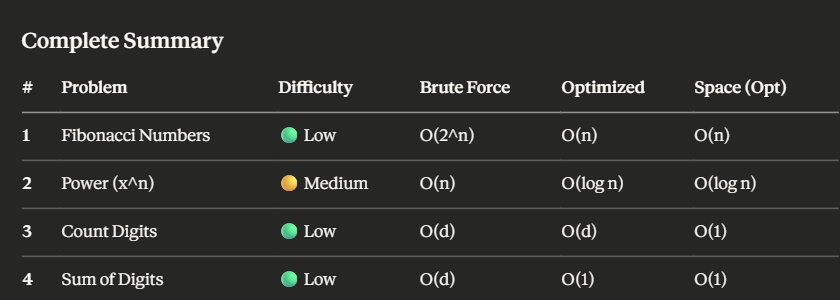